<a href="https://colab.research.google.com/github/jensjose07/deep_learning_lab/blob/main/expeiment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 253s 1us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Hidden units: (256, 128, 64) | Activation: relu    | Final Test Accuracy: 0.4380
Hidden units: (256, 128, 64) | Activation: tanh    | Final Test Accuracy: 0.4047
Hidden units: (256, 128, 64) | Activation: sigmoid | Final Test Accuracy: 0.4107
Hidden units: (512, 256, 128) | Activation: relu    | Final Test Accuracy: 0.4713
Hidden units: (512, 256, 128) | Activation: tanh    | Final Test Accuracy: 0.3773
Hidden units: (512, 256, 128) | Activation: sigmoid | Final Test Accuracy: 0.4311
Hidden units: (1024, 512, 256) | Activation: relu    | Final Test Accuracy: 0.4588
Hidden units: (1024, 512, 256) | Activation: tanh    | Final Test Accuracy: 0.3617
Hidden units: (1024, 512, 256) | Activation: sigmoid | Final Test Accuracy: 0.4395

FINAL ACCURACY OF ALL 9 COMBINATIONS
(256, 128, 64) + relu    -> 43.80%
(256, 128, 64) + tanh    -> 40.47%
(256, 128, 64) + sigmoid -> 41.07%
(512, 256, 128) + relu    -> 47.13%
(512, 256, 128) + tanh    -> 37.73%
(512, 256, 128) + sigmoid -> 43.11%
(1024, 512,

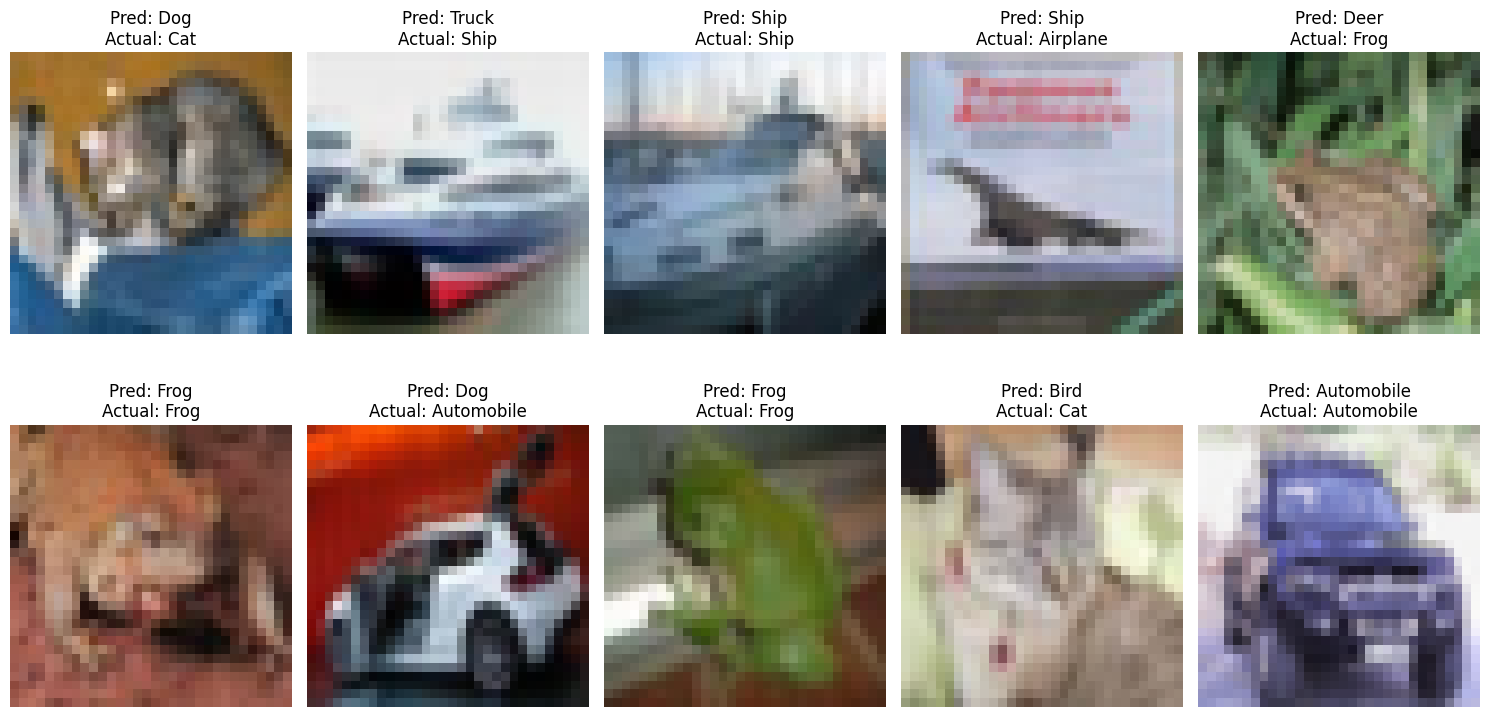

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# --------------------------------------------------
# Load CIFAR-10 dataset
# --------------------------------------------------
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# CIFAR-10 class names
class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

# --------------------------------------------------
# Different hidden-layer configurations
# --------------------------------------------------
hidden_configs = [
    (256, 128, 64),
    (512, 256, 128),
    (1024, 512, 256)
]

activations = ["relu", "tanh", "sigmoid"]

results = []

best_acc = 0
best_model = None
best_config = None

# --------------------------------------------------
# Train all combinations
# --------------------------------------------------
for hidden in hidden_configs:
    for activation in activations:

        model = Sequential([
            Flatten(input_shape=(32, 32, 3)),
            Dense(hidden[0], activation=activation),
            Dense(hidden[1], activation=activation),
            Dense(hidden[2], activation=activation),
            Dense(10, activation="softmax")
        ])

        model.compile(
            optimizer="adam",
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )

        model.fit(
            x_train,
            y_train,
            epochs=5,
            batch_size=128,
            validation_split=0.1,
            verbose=0
        )

        loss, accuracy = model.evaluate(
            x_test,
            y_test,
            verbose=0
        )

        results.append((hidden, activation, accuracy))

        print(
            f"Hidden units: {hidden} | "
            f"Activation: {activation:<7} | "
            f"Final Test Accuracy: {accuracy:.4f}"
        )

        # Store best model
        if accuracy > best_acc:
            best_acc = accuracy
            best_model = model
            best_config = (hidden, activation)


# --------------------------------------------------
# Display accuracy of all configurations
# --------------------------------------------------
print("\n" + "=" * 60)
print("FINAL ACCURACY OF ALL 9 COMBINATIONS")
print("=" * 60)

for hidden, activation, accuracy in results:
    print(
        f"{hidden} + {activation:<7} "
        f"-> {accuracy * 100:.2f}%"
    )


# --------------------------------------------------
# Best configuration
# --------------------------------------------------
print("\n" + "=" * 60)
print("BEST CONFIGURATION")
print("=" * 60)

print("Hidden units:", best_config[0])
print("Activation:", best_config[1])
print("Best Test Accuracy:", f"{best_acc * 100:.2f}%")


# --------------------------------------------------
# Predict first 10 test images
# --------------------------------------------------
num_images = 10

images = x_test[:num_images]

predictions = best_model.predict(
    images,
    verbose=0
)

predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(y_test[:num_images], axis=1)


# --------------------------------------------------
# Display 10 predictions
# --------------------------------------------------
plt.figure(figsize=(15, 8))

for i in range(num_images):

    plt.subplot(2, 5, i + 1)

    plt.imshow(images[i])

    predicted_name = class_names[predicted_classes[i]]
    actual_name = class_names[actual_classes[i]]

    plt.title(
        f"Pred: {predicted_name}\n"
        f"Actual: {actual_name}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()